## Netflix Movies and TV Shows

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from dash import Dash, dcc, html, Input, Output
import plotly.graph_objects as go
import numpy as np

df = pd.read_csv("sources/netflix_titles.csv")

/Users/amaurycaceres/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
#####Counting of nulls by each column

#show_id
print("* show_id column:")
print("Total - Not null: " + str(pd.notna(df.show_id).sum()) + " - Total nulls: " + str(pd.isna(df.show_id).sum()))
#df.type
print("* type column:")
print("Total - Not null: " + str(pd.notna(df.type).sum()) + " - Total nulls: " + str(pd.isna(df.type).sum()))
#df.title
print("* title column:")
print("Total - Not null: " + str(pd.notna(df.title).sum()) + " - Total nulls: " + str(pd.isna(df.title).sum()))
#df.director
print("* director column:")
print("Total - Not null: " + str(pd.notna(df.director).sum()) + " - Total nulls: " + str(pd.isna(df.director).sum()))
#df.cast
print("* cast column:")
print("Total - Not null: " + str(pd.notna(df.cast).sum()) + " - Total nulls: " + str(pd.isna(df.cast).sum()))
#df.country
print("* country column:")
print("Total - Not null: " + str(pd.notna(df.country).sum()) + " - Total nulls: " + str(pd.isna(df.country).sum()))
#df.date_added
print("* date_added column:")
print("Total - Not null: " + str(pd.notna(df.date_added).sum()) + " - Total nulls: " + str(pd.isna(df.date_added).sum()))
#df.release_year
print("* release_year column:")
print("Total - Not null: " + str(pd.notna(df.release_year).sum()) + " - Total nulls: " + str(pd.isna(df.release_year).sum()))
#df.rating
print("* rating column:")
print("Total - Not null: " + str(pd.notna(df.rating).sum()) + " - Total nulls: " + str(pd.isna(df.rating).sum()))
#df.duration
print("* duration column:")
print("Total - Not null: " + str(pd.notna(df.duration).sum()) + " - Total nulls: " + str(pd.isna(df.duration).sum()))
#df.listed_in
print("* listed_in column:")
print("Total - Not null: " + str(pd.notna(df.listed_in).sum()) + " - Total nulls: " + str(pd.isna(df.listed_in).sum()))
#df.description
print("* description column:")
print("Total - Not null: " + str(pd.notna(df.description).sum()) + " - Total nulls: " + str(pd.isna(df.description).sum()))
df.info()

* show_id column:
Total - Not null: 8807 - Total nulls: 0
* type column:
Total - Not null: 8807 - Total nulls: 0
* title column:
Total - Not null: 8807 - Total nulls: 0
* director column:
Total - Not null: 6173 - Total nulls: 2634
* cast column:
Total - Not null: 7982 - Total nulls: 825
* country column:
Total - Not null: 7976 - Total nulls: 831
* date_added column:
Total - Not null: 8797 - Total nulls: 10
* release_year column:
Total - Not null: 8807 - Total nulls: 0
* rating column:
Total - Not null: 8803 - Total nulls: 4
* duration column:
Total - Not null: 8804 - Total nulls: 3
* listed_in column:
Total - Not null: 8807 - Total nulls: 0
* description column:
Total - Not null: 8807 - Total nulls: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title    

I've noticed some null values in some columns. The next step will be cleaning those nulls and changing it for something more usable.
Also the data type are wrong in some columns.
# Cleaning
* The next columns will be cleaned of nulls:
    * Cast
    * Country
    * Date_added
    * Rating
    * Duration
    * Director

In [3]:
#Cast cleaning nulls - Inpace will add this change to the df 
df.cast.fillna('-',inplace=True)
#Country cleaning nulls - Inpace will add this change to the df 
df.country.fillna('-',inplace=True)
#date_added - This won't be cleaned due to the next data formatted change
#Rating
df.rating.fillna('-',inplace=True)
#duration
df.duration.fillna('-',inplace=True)
#director
df.director.fillna('-',inplace=True)

/var/folders/w8/yzw8c7gx72lbmqb53y6b4p4c0000gn/T/ipykernel_4144/3055166046.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.cast.fillna('-',inplace=True)
/var/folders/w8/yzw8c7gx72lbmqb53y6b4p4c0000gn/T/ipykernel_4144/3055166046.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a co

# Transformation

* The next columns will be formatted and changed the data type:
    * rating
* Multiple values in columns (Country, listed_in):  
The columns will be left as how is it now.

In [4]:
#Changing data type
df.date_added = pd.to_datetime(df.date_added, errors='coerce')
#Due to this change, we will have nulls antother time on this column. But it's worth it, now we have it with the correct data type

# Visualizations
On this section I will create the charts to better understanding of the dataset we have. Due to the data we have, I will need  
to separate the tv shows and movies. Why? The duration are different in both of them, movies durations are in minutes and tv shows in seasons



# TV shows and Movies
* Donut chart: Comparision of how much of the are in the catalog
* Stacked bar chart with the country and the type. Or maybe map chart, with both of the types added.
* Line chart: Will show which of them are more important to netflix


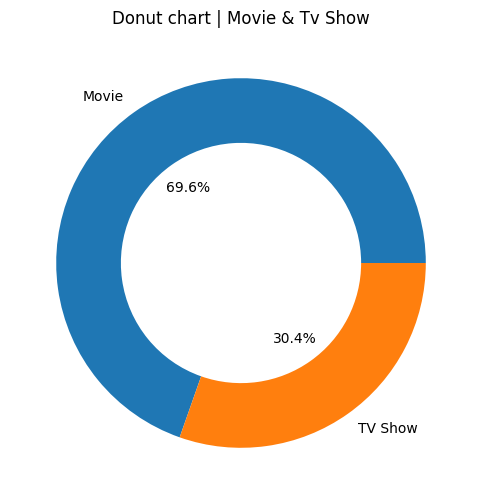

In [5]:
#Donut chart
groupped_by_type = df.groupby("type").count().show_id
plt.figure(figsize=(6,6))
plt.title("Donut chart | Movie & Tv Show")
plt.pie(groupped_by_type, labels=groupped_by_type.index,autopct='%1.1f%%', pctdistance=0.5,wedgeprops=dict(width=0.35))
plt.show()

In [6]:
#Map 
df_map = df.copy()

df_map.country = (df_map.country
.str.strip()
.replace("-","")
.str.strip()
.str.replace(r",\s*$", "", regex=True)
.str.strip()
.str.split(r"\s*,\s*")
)

df_map = df_map.explode("country",ignore_index=True)

##
country_summary = (
    df_map.groupby("country")
    .agg(
        Total=("show_id", "count"),
        Movies=("type", lambda x: (x == "Movie").sum()),
        Shows=("type", lambda x: (x == "TV Show").sum()) 
    )
    .reset_index()
)

fig = px.choropleth(
    country_summary,
    locations="country",
    locationmode="country names",
    color="Total",
    hover_name="country",
    hover_data={
        "Total": True,
        "Movies": True,
        "Shows": True
    },
    color_continuous_scale="Reds",
    projection="natural earth"
)


fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
fig.show()

/var/folders/w8/yzw8c7gx72lbmqb53y6b4p4c0000gn/T/ipykernel_4144/2350584815.py:26: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


In [7]:
df_copy = df.copy()
df_copy["month_year"] = df_copy["date_added"].dt.to_period("M").astype(str)

type_by_year = (
    df_copy.groupby(["month_year","type"])
    .agg(
        Total=("show_id", "count"),
    )
    .reset_index()
)

fig = px.line(type_by_year, x="month_year", y="Total", color="type",title="Movie/Tv Show Trend")
fig.show()

# Tv Shows Visualizations

In [8]:
#Filter visual
app = Dash(__name__)

#Filter
df_map_listed = df.copy()

#Explode listed_in
df_map_listed.listed_in = (df_map_listed.listed_in
.str.strip()
.replace("-","")
.str.strip()
.str.replace(r",\s*$", "", regex=True)
.str.strip()
.str.split(r"\s*,\s*")
)

df_map_listed = df_map_listed.explode("listed_in",ignore_index=True)
df_map_listed = df_map_listed[df_map_listed["type"] == "TV Show"]

filter_values = df_map_listed.listed_in.value_counts().index.to_numpy()
#Explode country
df_map_listed.country = (df_map_listed.country
.str.strip()
.replace("-","")
.str.strip()
.str.replace(r",\s*$", "", regex=True)
.str.strip()
.str.split(r"\s*,\s*")
)

df_map_listed = df_map_listed.explode("country",ignore_index=True)

df_map_listed["country"] = df_map_listed["country"].str.strip()
df_map_listed["country"] = df_map_listed["country"].replace(r"^\s*$", pd.NA, regex=True)
df_map_listed = df_map_listed.dropna(subset=["country"])
#df grouped
country_listed = (
    df_map_listed.groupby(["country","listed_in"])
    .agg(
        Total=("show_id", "count")        
    )
    .reset_index()
)

#Creation of the filter
app.layout = html.Div([
    html.H4('Type of TV Show in Country'),
    dcc.Dropdown(
        id="dropdownTv",
        options=filter_values,
        value=filter_values[0],
        clearable=False,
    ),
    dcc.Graph(id="graphTv"),
],style={"backgroundColor": "white"})

#Creation of the graph
@app.callback(
    Output("graphTv", "figure"),
    Input("dropdownTv", "value"))
def update_bar_chart(listed_in_value):
    df = country_listed 
    mask = df.listed_in == listed_in_value
    fig = px.bar(df[mask], x="country", y="Total")
    return fig

app.run(debug=True,port=8051)

In [9]:
df_heatmap = df_map_listed.copy()
df_heatmap = df_heatmap[df_heatmap["type"] == "TV Show"]

top_countries = df_heatmap["country"].value_counts().head(15).index
top_listed = df_heatmap["listed_in"].value_counts().head(10).index

df_heatmap = df_heatmap[
    df_heatmap["country"].isin(top_countries) &
    df_heatmap["listed_in"].isin(top_listed)
]

df_heatmap = (
    df_heatmap.groupby(["listed_in", "country"])
    .agg(Total=("show_id", "count"))
    .reset_index()
)

df_heatmap = df_heatmap.pivot(
    index="country",
    columns="listed_in",
    values="Total"
).fillna(0)

fig = px.imshow(df_heatmap)
fig.show()

In [10]:
# from datetime import datetime
# media = df["mi_columna"].mean()

# fig = go.Figure(go.Indicator(
#     mode="number",
#     value=media,
#     title={"text": "Media"}
# ))

# fig.show()
df_avg = df_map_listed.copy()
# df_avg.release_year = int(df_avg.release_year)
# df_avg.year_added = df_avg.date_added
df_avg = df_avg[df_avg.type == "TV Show"]
df_avg = df_avg.dropna(subset=["date_added"])
df_avg["aux_year_added"] = pd.to_datetime(df_avg.date_added).dt.year
df_avg["release_to_addde"] = df_avg.aux_year_added - df_avg.release_year

avg_result = df_avg["release_to_addde"].mean()

fig = go.Figure(go.Indicator(
    mode="number",
    value=avg_result,
    number={"valueformat": ".2f"},
    title={"text": "Tv Show: Years from the release to the catalog"}
))

fig.show()

# Movies visualization

In [11]:
#Filter visual
app1 = Dash(__name__)

#Filter
df_map_listed_movie = df.copy()

#Explode listed_in
df_map_listed_movie.listed_in = (df_map_listed_movie.listed_in
.str.strip()
.replace("-","")
.str.strip()
.str.replace(r",\s*$", "", regex=True)
.str.strip()
.str.split(r"\s*,\s*")
)

df_map_listed_movie = df_map_listed_movie.explode("listed_in",ignore_index=True)
df_map_listed_movie = df_map_listed_movie[df_map_listed_movie["type"] == "Movie"]

filter_values = df_map_listed_movie.listed_in.value_counts().index.to_numpy()
#Explode country
df_map_listed_movie.country = (df_map_listed_movie.country
.str.strip()
.replace("-","")
.str.strip()
.str.replace(r",\s*$", "", regex=True)
.str.strip()
.str.split(r"\s*,\s*")
)

df_map_listed_movie = df_map_listed_movie.explode("country",ignore_index=True)

df_map_listed_movie["country"] = df_map_listed_movie["country"].str.strip()
df_map_listed_movie["country"] = df_map_listed_movie["country"].replace(r"^\s*$", pd.NA, regex=True)
df_map_listed_movie = df_map_listed_movie.dropna(subset=["country"])
#df grouped
country_listedMovie = (
    df_map_listed_movie.groupby(["country","listed_in"])
    .agg(
        Total=("show_id", "count")        
    )
    .reset_index()
)

#Creation of the filter
app1.layout = html.Div([
    html.H4('Type of Movie in Country'),
    dcc.Dropdown(
        id="dropdownMovie",
        options=filter_values,
        value=filter_values[0],
        clearable=False,
    ),
    dcc.Graph(id="graphMovie"),
],style={"backgroundColor": "white"})

#Creation of the graph
@app1.callback(
    Output("graphMovie", "figure"),
    Input("dropdownMovie", "value"))
def update_bar_chart(listed_in_value):
    df = country_listedMovie
    mask = df.listed_in == listed_in_value
    fig = px.bar(df[mask], x="country", y="Total")
    return fig

app1.run(debug=True)

In [12]:
df_heatmap = df_map_listed_movie.copy()
# df_heatmap = df_heatmap[df_heatmap["type"] == "Movie"]

top_countries = df_heatmap["country"].value_counts().head(15).index
top_listed = df_heatmap["listed_in"].value_counts().head(10).index

df_heatmap = df_heatmap[
    df_heatmap["country"].isin(top_countries) &
    df_heatmap["listed_in"].isin(top_listed)
]

df_heatmap = (
    df_heatmap.groupby(["listed_in", "country"])
    .agg(Total=("show_id", "count"))
    .reset_index()
)

df_heatmap = df_heatmap.pivot(
    index="country",
    columns="listed_in",
    values="Total"
).fillna(0)

fig = px.imshow(df_heatmap)
fig.show()

In [13]:
df_avg = df_map_listed_movie.copy()
# df_avg = df_avg[df_avg.type == "Movie"]
df_avg = df_avg.dropna(subset=["date_added"])
df_avg["aux_year_added"] = pd.to_datetime(df_avg.date_added).dt.year
df_avg["release_to_addde"] = df_avg.aux_year_added - df_avg.release_year

avg_result = df_avg["release_to_addde"].mean()

fig = go.Figure(go.Indicator(
    mode="number",
    value=avg_result,
    number={"valueformat": ".2f"},
    title={"text": "Movie: Years from the release to the catalog"}
))

fig.show()

# EDA 

Here I will focus on a category of the Tv Shows/Movies. The category I'll be focused here, will be 'Anime', I want to see the evolution of this genre through the dataset.

In [14]:
df_anime = df.copy()

#Exploding listed_in. Here is the genre
df_anime.listed_in = (df_anime.listed_in
.str.strip()
.replace("-","")
.str.strip()
.str.replace(r",\s*$", "", regex=True)
.str.strip()
.str.split(r"\s*,\s*")
)
df_anime = df_anime.explode("listed_in",ignore_index=True)

#Selection only Anime
df_anime = df_anime[df_anime["listed_in"].str.contains("anime", case=False, na=False)]

#Explode country
df_anime.country = (df_anime.country
.str.strip()
.replace("-","")
.str.strip()
.str.replace(r",\s*$", "", regex=True)
.str.strip()
.str.split(r"\s*,\s*")
)

df_anime = df_anime.explode("country",ignore_index=True)

In [15]:
df_anime_copy = df_anime.copy()
df_anime_copy["month_year"] = df_anime_copy["date_added"].dt.to_period("M").astype(str)

type_by_year_anime = (
    df_anime_copy.groupby(["month_year","type"])
    .agg(
        Total=("show_id", "count"),
    )
    .reset_index()
)

fig = px.line(type_by_year_anime, x="month_year", y="Total", color="type",title="Anime trend")
fig.show()

In [16]:
df_avg_anime = df_anime.copy()

df_avg_anime = df_avg_anime.dropna(subset=["date_added"])
df_avg_anime["aux_year_added"] = pd.to_datetime(df_avg_anime.date_added).dt.year
df_avg_anime["release_to_addde"] = df_avg_anime.aux_year_added - df_avg_anime.release_year

df_avg_anime_tv = df_avg_anime[df_avg_anime.type == "Movie"]
df_avg_anime_tv = df_avg_anime_tv["release_to_addde"].mean()

fig = go.Figure(go.Indicator(
    mode="number",
    value=df_avg_anime_tv,
    number={"valueformat": ".2f"},
    title={"text": "Tv Show: Years from the release to the catalog"}
))

fig.show()

df_avg_anime_movie = df_avg_anime[df_avg_anime.type == "TV Show"]
df_avg_anime_movie = df_avg_anime["release_to_addde"].mean()

figMovie = go.Figure(go.Indicator(
    mode="number",
    value=df_avg_anime_movie,
    number={"valueformat": ".2f"},
    title={"text": "Movie: Years from the release to the catalog"}
))

figMovie.show()



In [17]:
#Creation of new columns

#I decided to delete this nulls because It't not usable and only were 4 rows.
df_anime = df_anime.dropna(subset=["date_added"])
df_anime["year_added"] = pd.to_datetime(df_anime.date_added).dt.year
df_anime["month_added"] = pd.to_datetime(df_anime.date_added).dt.month

In [18]:
df_growth = df_anime.copy()
df_growth = (df_growth.groupby("year_added")
.agg(Total=("show_id", "count")))

df_growth["growth_pct"] = (df_growth['Total'].pct_change() * 100).round(2)
df_growth = df_growth.dropna()

#Waterfall graph
fig = go.Figure(go.Waterfall(
    name = "20", orientation = "v",
    x = df_growth.index,
    textposition = "outside",
    y = df_growth.growth_pct,
    connector = {"line":{"color":"rgb(63, 63, 63)"}},
))

fig.update_layout(
        title = "Growth of anime in Netflix (2016-2021)",
        showlegend = True
)

fig.show()


In [19]:
pctMean=df_growth.growth_pct.mean()
figMeanInc = go.Figure(go.Indicator(
    mode="number",
    value=pctMean,
    number={"valueformat": ".2f"},
    title={"text": "average increase %"}
))

figMeanInc.show()

In [22]:
df_gb_rating = df_anime.copy()

#Dropping empty values
df_gb_rating["country"] = df_gb_rating["country"].replace("", np.nan)
df_gb_rating = df_gb_rating.dropna(subset=["country"])

df_gb_rating=df_gb_rating.groupby(['country','rating']).agg(
    Total=("show_id","count")).reset_index()



labels = pd.unique(pd.concat([df_gb_rating["rating"], df_gb_rating["country"]], ignore_index=True))
label_to_idx = {label: i for i, label in enumerate(labels)}



df_gb_rating["source"] = df_gb_rating["rating"].map(label_to_idx)
df_gb_rating["target"] = df_gb_rating["country"].map(label_to_idx)

# Countries
countries = df_gb_rating["country"].unique()

# Palette
palette = px.colors.qualitative.Plotly

country_colors = {
    country: palette[i % len(palette)]
    for i, country in enumerate(countries)
}

# Color node
node_colors = []
for label in labels:
    if label in country_colors:
        node_colors.append(country_colors[label])
    else:
        node_colors.append("lightgray")   

df_gb_rating["link_color"] = df_gb_rating["country"].map(country_colors)

fig = go.Figure(data=[go.Sankey(
   node=dict(
       pad=15,
       thickness=20,
       label=labels,
       color=node_colors

   ),
   link=dict(
       source=df_gb_rating["source"],
       target=df_gb_rating["target"],
       value=df_gb_rating["Total"],
       color=df_gb_rating["link_color"]
   )
)])


fig.show()


In [26]:
df_anime.groupby("country").agg(
    Total=("show_id", "count")
).reset_index()


,country,Total
0,,30
1,Australia,1
2,Canada,2
3,China,4
4,Indonesia,1
5,Japan,200
6,Philippines,1
7,Singapore,1
8,Spain,1
9,United States,25
